In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# CONFIGURACIÓN DEL PROYECTO
# ==========================================
PATH_BASE = "./dataset-cazas"        # Carpeta de entrenamiento
PATH_TEST = "./dataset-test"         # Carpeta de pruebas externas
MODELO_BINARIO = "cazas_final.keras" # Archivo físico del modelo
CLASES_FILE = "clases_nombres.npy"   # Archivo para nombres de aviones

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0001
# ==========================================

I0000 00:00:1773950475.902582    5158 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Verificación de Imágenes

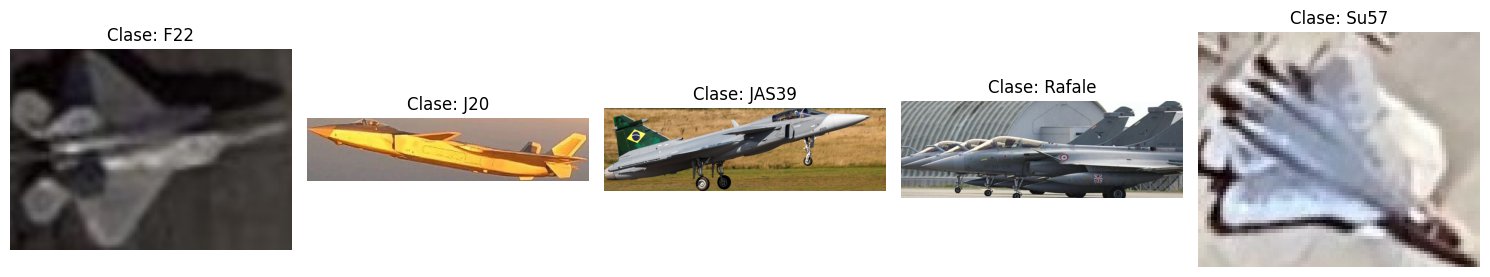

In [2]:
folders = sorted([f for f in os.listdir(PATH_BASE) if os.path.isdir(os.path.join(PATH_BASE, f))])
fig, axes = plt.subplots(1, len(folders), figsize=(15, 5))

for i, name in enumerate(folders):
    folder_path = os.path.join(PATH_BASE, name)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if files:
        img = mpimg.imread(os.path.join(folder_path, files[0]))
        axes[i].imshow(img)
        axes[i].set_title(f"Clase: {name}")
        axes[i].axis('off')

plt.tight_layout()
plt.show() # Para tu notebook usa show() para ver resultados inmediatos

# Carga de Datos y Optimización

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_BASE, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_BASE, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
np.save(CLASES_FILE, class_names)

# Optimización de Memoria
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3555 files belonging to 5 classes.
Using 2844 files for training.
Found 3555 files belonging to 5 classes.
Using 711 files for validation.


# Arquitectura EfficientNetB0 (Transfer Learning)

In [4]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False 

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento y Guardado del Binario

In [5]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(MODELO_BINARIO, save_best_only=True, monitor='val_accuracy')

history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS, 
    callbacks=[checkpoint]
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.2359 - loss: 2.3619 - val_accuracy: 0.2602 - val_loss: 1.6412
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 373s 4s/step - accuracy: 0.2764 - loss: 2.0904 - val_accuracy: 0.3474 - val_loss: 1.5735
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.3175 - loss: 1.9426 - val_accuracy: 0.3896 - val_loss: 1.5142
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.3562 - loss: 1.8000 - val_accuracy: 0.4219 - val_loss: 1.4565
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.3991 - loss: 1.6711 - val_accuracy: 0.4557 - val_loss: 1.3969
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.4191 - loss: 1.6031 - val_accuracy: 0.4965 - val_loss: 1.3339
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.4634 - loss: 1.4733 - val_accuracy: 0.5288 - val_loss: 1.2757
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.4673 - loss: 1.4482 - val_accuracy: 0.5527 - v

# Fine tuning

In [6]:
# 1. Desbloqueamos el modelo base para que sus filtros se ajusten
base_model.trainable = True

# 2. IMPORTANTE: Bajamos la velocidad de aprendizaje (Learning Rate)
# Usamos 1e-5 (0.00001) para no destruir el conocimiento previo de ImageNet
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamos
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=[checkpoint]
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1502s 16s/step - accuracy: 0.3924 - loss: 1.6979 - val_accuracy: 0.5696 - val_loss: 1.1847
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1416s 16s/step - accuracy: 0.4248 - loss: 1.5378 - val_accuracy: 0.5767 - val_loss: 1.1403
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1422s 16s/step - accuracy: 0.4838 - loss: 1.3887 - val_accuracy: 0.5851 - val_loss: 1.0869
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1440s 16s/step - accuracy: 0.5158 - loss: 1.2543 - val_accuracy: 0.6076 - val_loss: 1.0236
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1437s 16s/step - accuracy: 0.5608 - loss: 1.1608 - val_accuracy: 0.6301 - val_loss: 0.9717
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1401s 16s/step - accuracy: 0.5925 - loss: 1.0725 - val_accuracy: 0.6554 - val_loss: 0.9215
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1448s 16s/step - accuracy: 0.6322 - loss: 0.9978 - val_accuracy: 0.6737 - val_loss: 0.8786
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1486s 17s/step - accuracy: 0.6624 - loss: 0.9030 - val_accu

# Comportamiento del entrenamiento

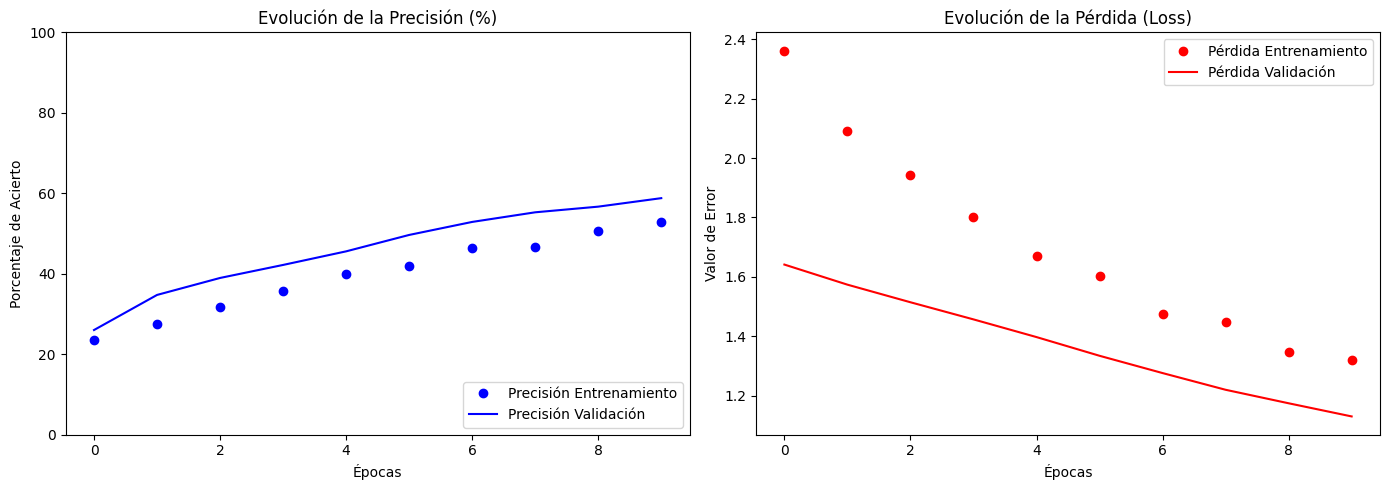

In [7]:
# =============================================================
# CELDA 13: Graficar historial de entrenamiento
# =============================================================

# Extraer historial del objeto 'history' (el que usamos en el fit de cazas)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Crear la figura con dos sub-gráficas
plt.figure(figsize=(14, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
plt.subplot(1, 2, 1)
# Puntos azules para entrenamiento, línea azul para validación
plt.plot(epochs_range, [x * 100 for x in acc], 'bo', label='Precisión Entrenamiento')
plt.plot(epochs_range, [x * 100 for x in val_acc], 'b', label='Precisión Validación')
plt.title('Evolución de la Exactitud (%)')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje de Acierto')
plt.ylim(0, 100) # Forzamos de 0 a 100 para que se vea real
plt.legend(loc='lower right')

# --- Gráfica 2: Pérdida (Loss) ---
plt.subplot(1, 2, 2)
# Puntos rojos para entrenamiento, línea roja para validación
plt.plot(epochs_range, loss, 'ro', label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, 'r', label='Pérdida Validación')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Valor de Error')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# CARGA Y REPORTE

In [8]:
# Cargamos el binario para asegurar que el reporte sea del modelo real en disco
model_ready = tf.keras.models.load_model(MODELO_BINARIO)
labels = np.load(CLASES_FILE)

y_true, y_pred = [], []
for x, y in val_ds:
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(model_ready.predict(x, verbose=0), axis=-1))

print("\n" + "="*60)
print("             REPORTE DE CLASIFICACIÓN DETALLADO")
print("="*60)
# Esto muestra Precision, Recall, F1-Score y Support por cada avión
print(classification_report(y_true, y_pred, target_names=labels))


             REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

         F22       0.72      0.73      0.72       142
         J20       0.73      0.84      0.78       182
       JAS39       0.71      0.56      0.62       117
      Rafale       0.74      0.75      0.74       174
        Su57       0.67      0.62      0.65        96

    accuracy                           0.72       711
   macro avg       0.71      0.70      0.70       711
weighted avg       0.72      0.72      0.72       711



# MATRIZ DE CONFUSIÓN

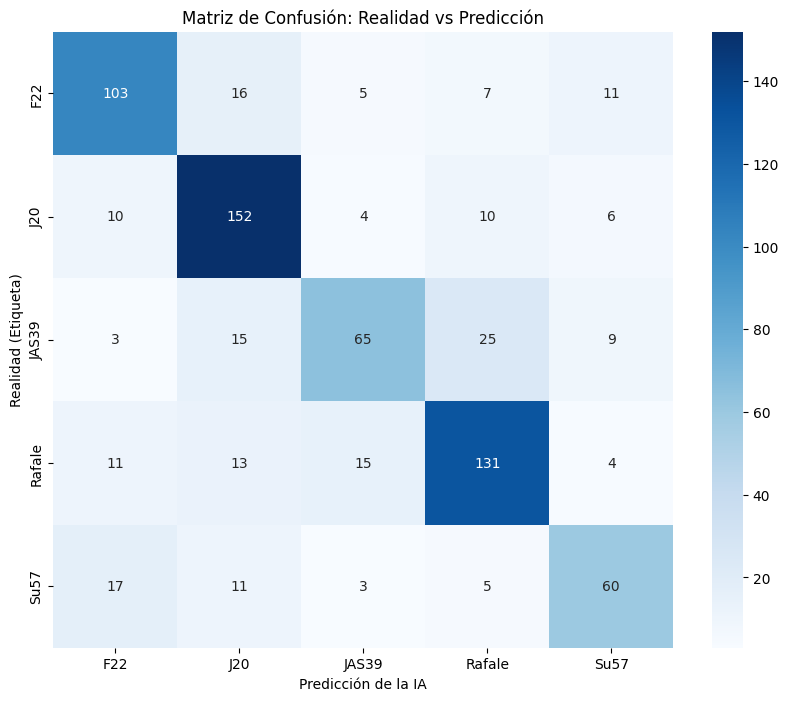

In [9]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión: Realidad vs Predicción')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (Etiqueta)')
plt.show()

# VISUALIZADOR DE ACIERTOS Y ERRORES

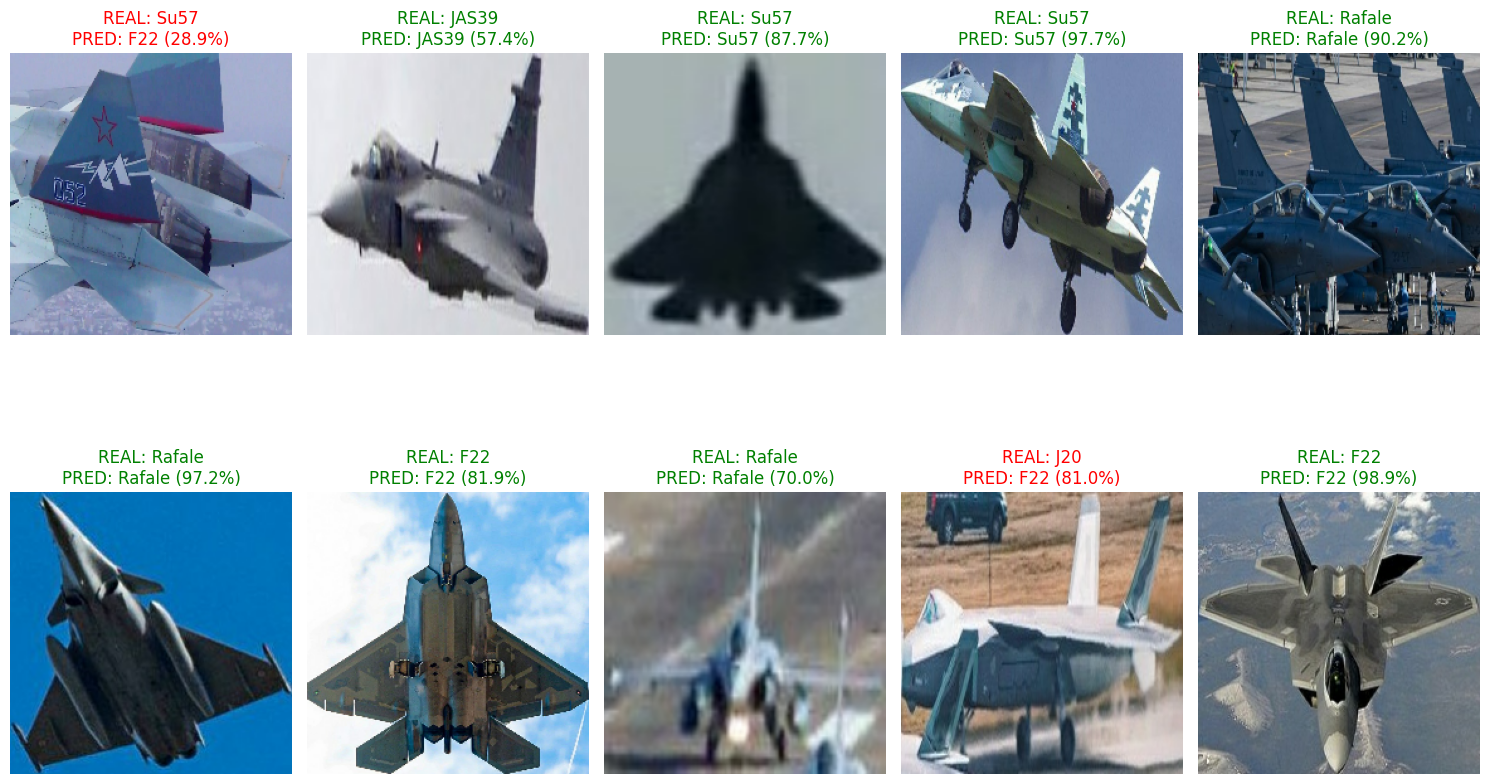

In [10]:
plt.figure(figsize=(15, 10))
# Tomamos fotos del set de validación
for images, labels_batch in val_ds.take(1):
    preds = model_ready.predict(images, verbose=0)
    
    for i in range(10): # Mostramos las primeras 10 fotos
        actual = labels[labels_batch[i]]
        pred_idx = np.argmax(preds[i])
        predicho = labels[pred_idx]
        confianza = 100 * np.max(preds[i])
        
        color = 'green' if actual == predicho else 'red'
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"REAL: {actual}\nPRED: {predicho} ({confianza:.1f}%)", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Prueba con Carpeta Test

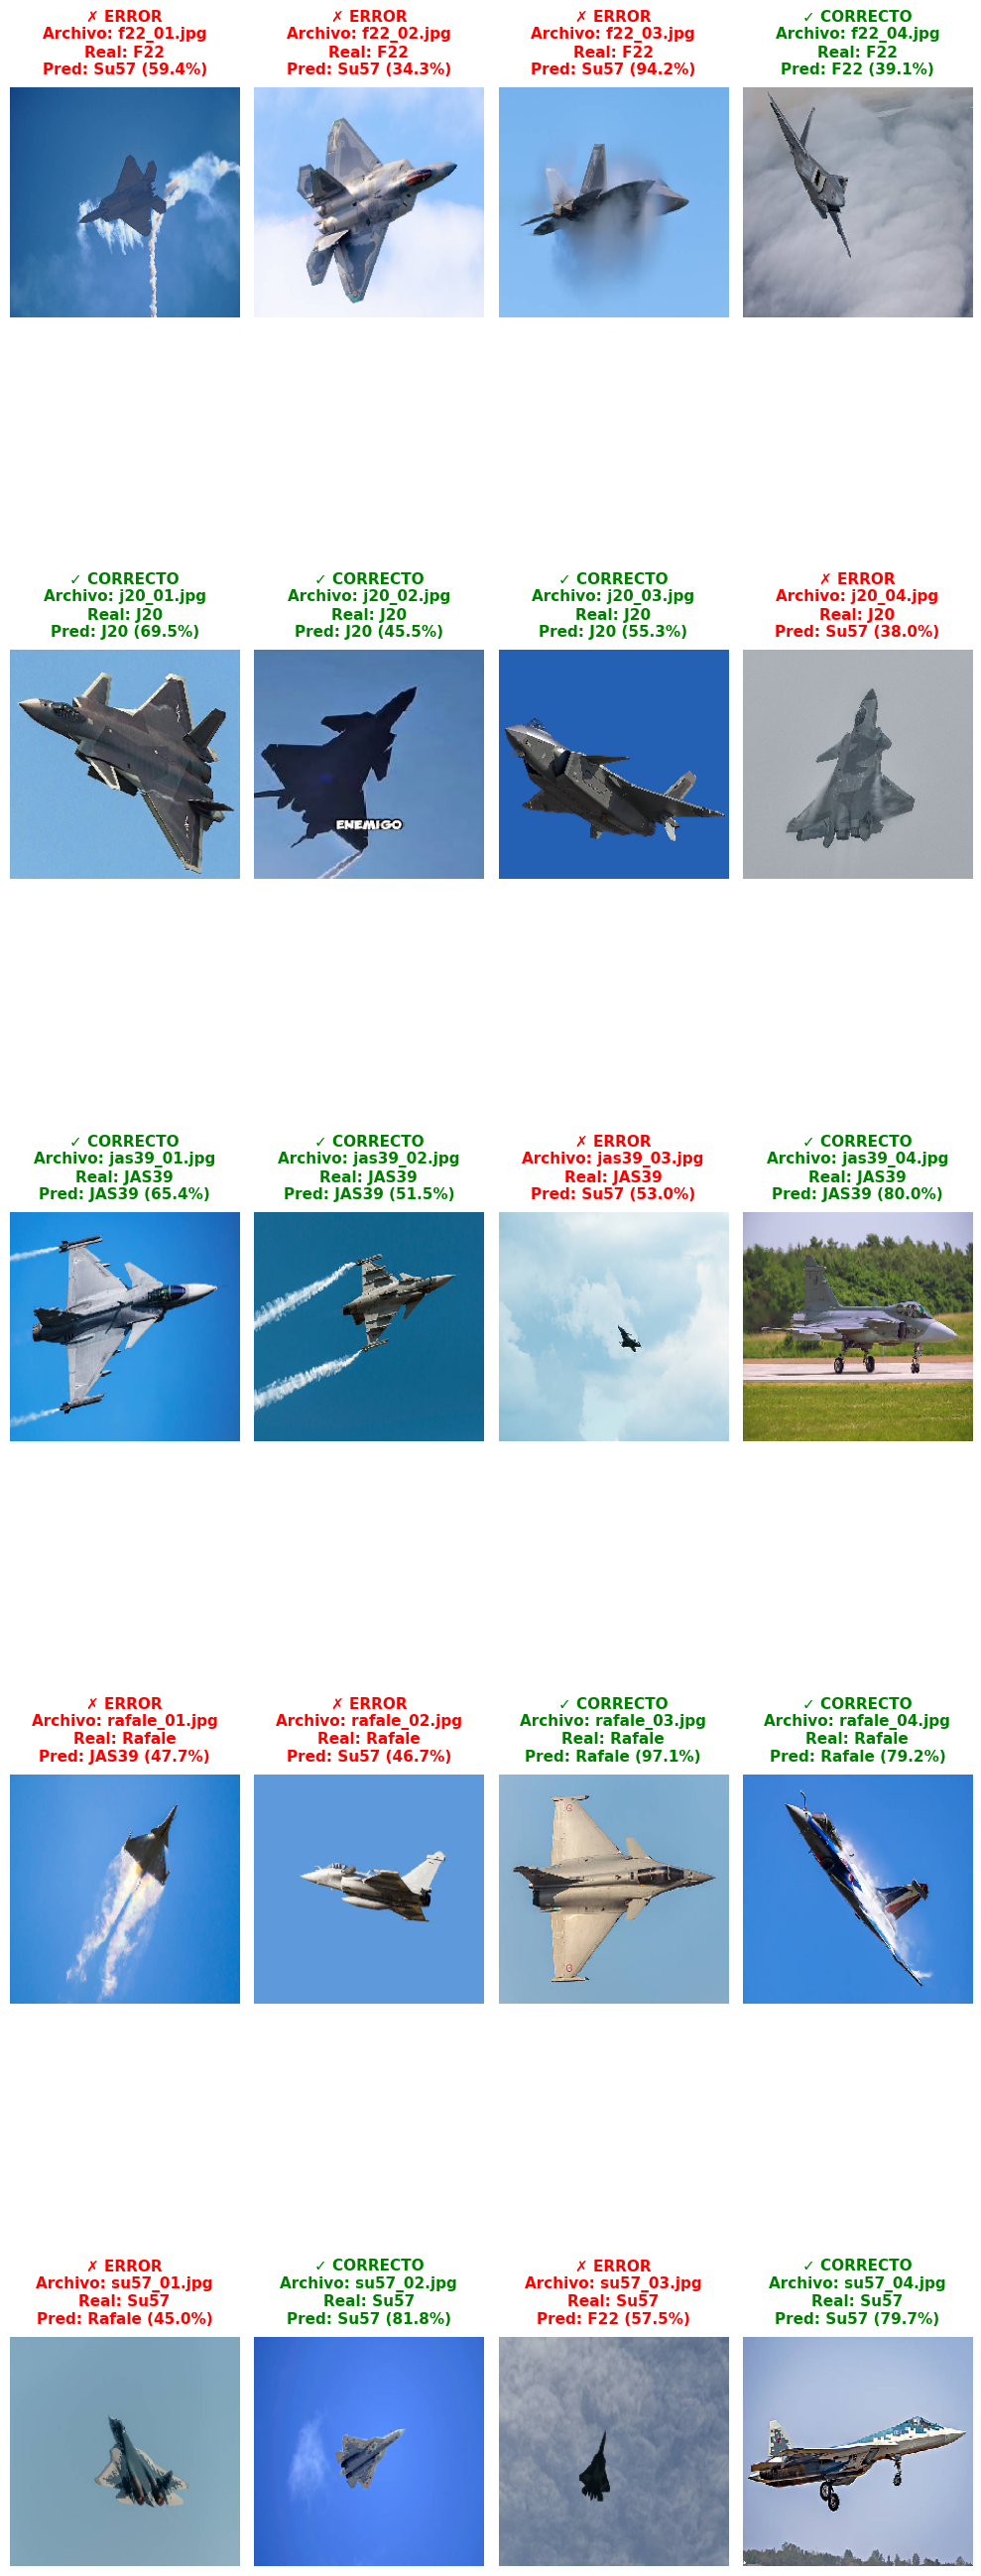

In [11]:
def prueba_maestra_test(folder, num_fotos=20):
    import os
    
    exts = ('.jpg', '.jpeg', '.png', '.webp')
    archivos = sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])
    
    if not archivos:
        return print(f"No se encontraron fotos en {folder}")

    cols = 4
    n_fotos = min(len(archivos), num_fotos)
    rows = (n_fotos + cols - 1) // cols
    
    plt.figure(figsize=(10, rows * 6)) 
    
    for i, filename in enumerate(archivos[:n_fotos]):
        path = os.path.join(folder, filename)
        
        # --- Predicción ---
        img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)
        
        preds = model_ready.predict(img_batch, verbose=0)
        pred_idx = np.argmax(preds[0])
        clase_predicha = labels[pred_idx]
        confianza = 100 * preds[0][pred_idx]
        
        # --- Lógica de Verificación Flexible ---
        es_correcto = False
        nombre_real = "Desconocido"
        
        # Normalizamos el nombre del archivo (quitamos guiones y pasamos a minúsculas)
        fname_norm = filename.lower().replace("-", "").replace("_", "")
        
        for nombre_clase in labels:
            # Normalizamos también el nombre de la clase (carpeta)
            clase_norm = nombre_clase.lower().replace("-", "").replace("_", "")
            
            # Si el nombre normalizado de la clase está en el nombre del archivo
            if clase_norm in fname_norm:
                nombre_real = nombre_clase
                if nombre_clase == clase_predicha:
                    es_correcto = True
                break
        
        # --- Visualización ---
        color = 'green' if es_correcto else 'red'
        if nombre_real == "Desconocido": color = 'orange' # Naranja si no se pudo validar
            
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        
        resultado_txt = "✓ CORRECTO" if es_correcto else "✗ ERROR"
        if nombre_real == "Desconocido": resultado_txt = "? NO ETIQUETADO"

        titulo = f"{resultado_txt}\nArchivo: {filename}\nReal: {nombre_real}\nPred: {clase_predicha} ({confianza:.1f}%)"
        plt.title(titulo, color=color, fontsize=11, fontweight='bold', pad=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecución
prueba_maestra_test(PATH_TEST, num_fotos=20)